# Twitter Image Probing Analysis
Load saved probing outputs, visualize image-level heatmaps, and inspect aggregate statistics for Twitter images.

In [10]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
sns.set_style("whitegrid")

In [11]:
# Load the requested Twitter-image probing outputs.
SCORES_PATH = Path("results/qwen3-vl-8b-instruct/twitter_images_patch_scores.pt")
STATS_PATH = Path("results/qwen3-vl-8b-instruct/twitter_images_patch_stats.csv")

if not SCORES_PATH.exists():
    raise FileNotFoundError(f"Missing scores file: {SCORES_PATH}")
if not STATS_PATH.exists():
    raise FileNotFoundError(f"Missing stats file: {STATS_PATH}")

payload = torch.load(SCORES_PATH, map_location="cpu")
df_stats = pd.read_csv(STATS_PATH)

print(f"Loaded scores: {SCORES_PATH}")
print(f"Loaded stats : {STATS_PATH}")
print(f"Num images   : {len(payload['image_paths'])}")
print("Metadata:")
display(pd.Series(payload.get("metadata", {}), name="value"))

df_stats.head()

Loaded scores: results/qwen3-vl-8b-instruct/twitter_images_patch_scores.pt
Loaded stats : results/qwen3-vl-8b-instruct/twitter_images_patch_stats.csv
Num images   : 1367
Metadata:


model_path         /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
image_dir                                       data/twitter_images
ridge_prefix                                             politician
top_k                                                            16
prompt            Analyze this image. What political perspective...
max_width                                                       800
image_pad_id                                                 151655
skipped_images                                                    0
Name: value, dtype: object

,image_name,image_path,grid_h,grid_w,num_patches,mean,median,min,max,std
0,C1a1PdgUAAAklBh.jpg,data/twitter_images/C1a1PdgUAAAklBh.jpg,14,25,350,-0.118283,-0.070190,-1.396973,0.437988,0.272070
1,D--5-MNWwAAetf3.jpg,data/twitter_images/D--5-MNWwAAetf3.jpg,19,25,475,-0.115715,-0.110447,-0.993652,0.790405,0.184499
2,D-4ykA4WwAEE2Eg.jpg,data/twitter_images/D-4ykA4WwAEE2Eg.jpg,14,25,350,-0.233668,-0.228271,-0.766418,0.207520,0.171030
3,D-Aa167X4AIFt9H.png,data/twitter_images/D-Aa167X4AIFt9H.png,14,25,350,-0.306140,-0.308873,-0.767822,0.236206,0.163919
4,D-_ZcWXXYAEdxhr.jpg,data/twitter_images/D-_ZcWXXYAEdxhr.jpg,25,25,625,-0.036504,-0.033997,-0.972412,0.796089,0.230187


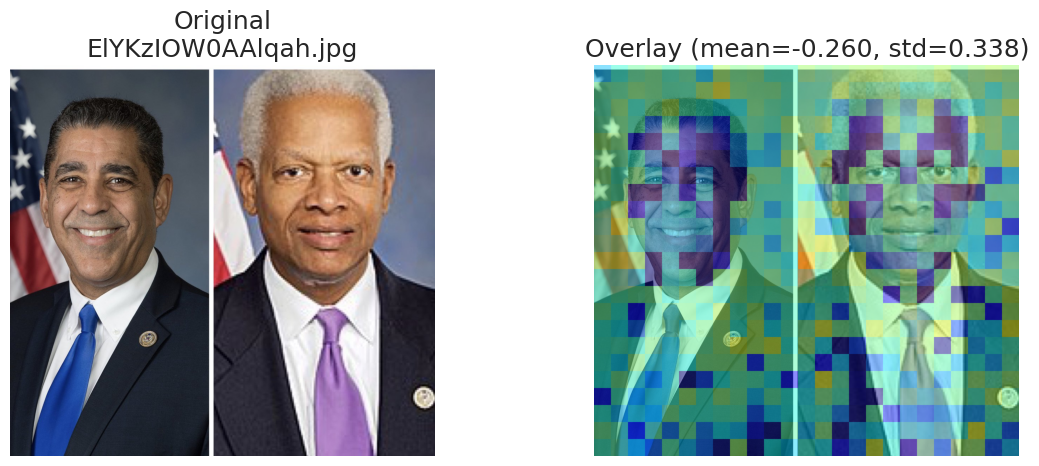

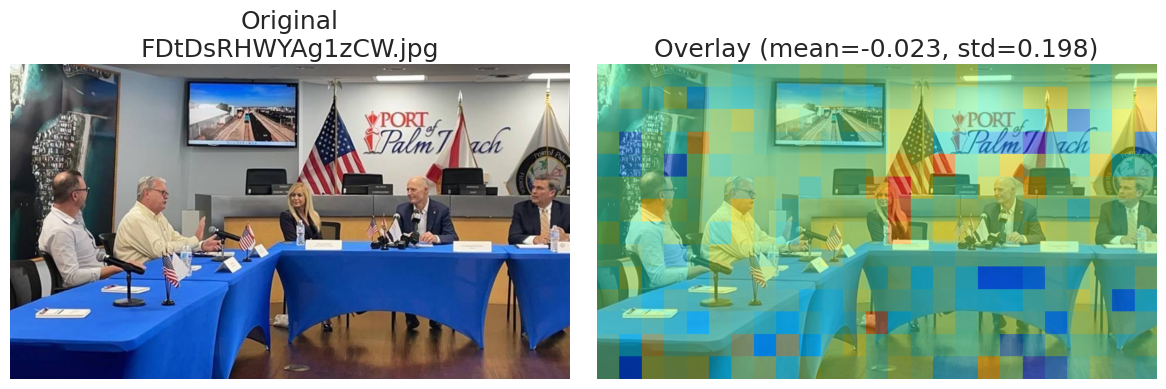

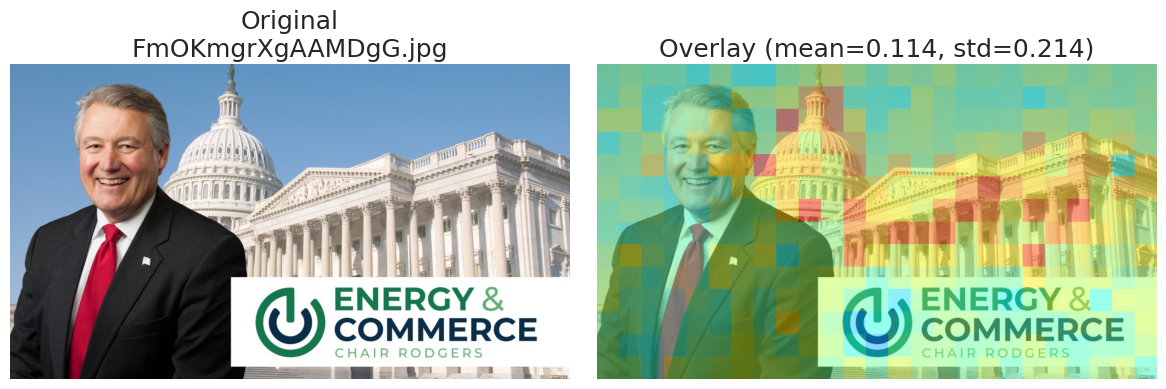

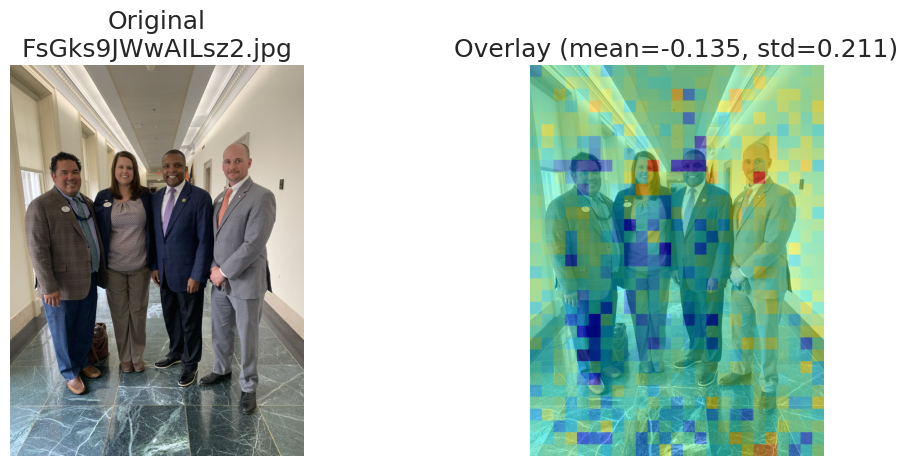

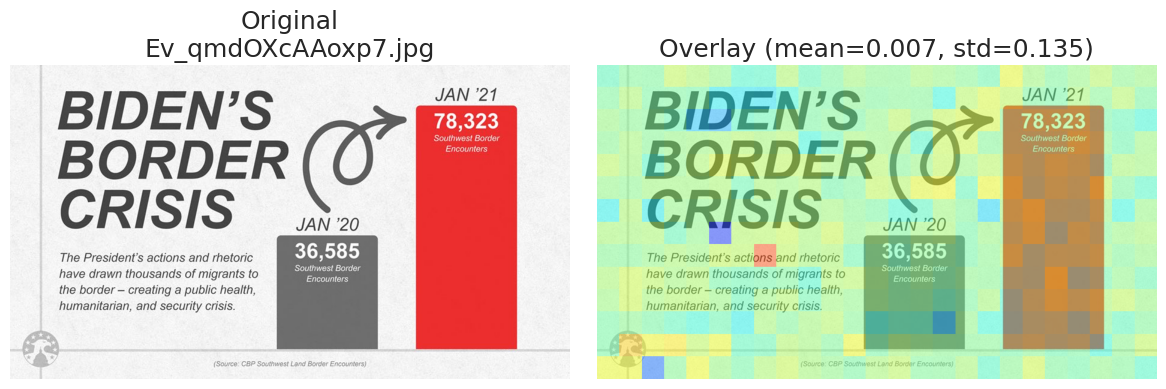

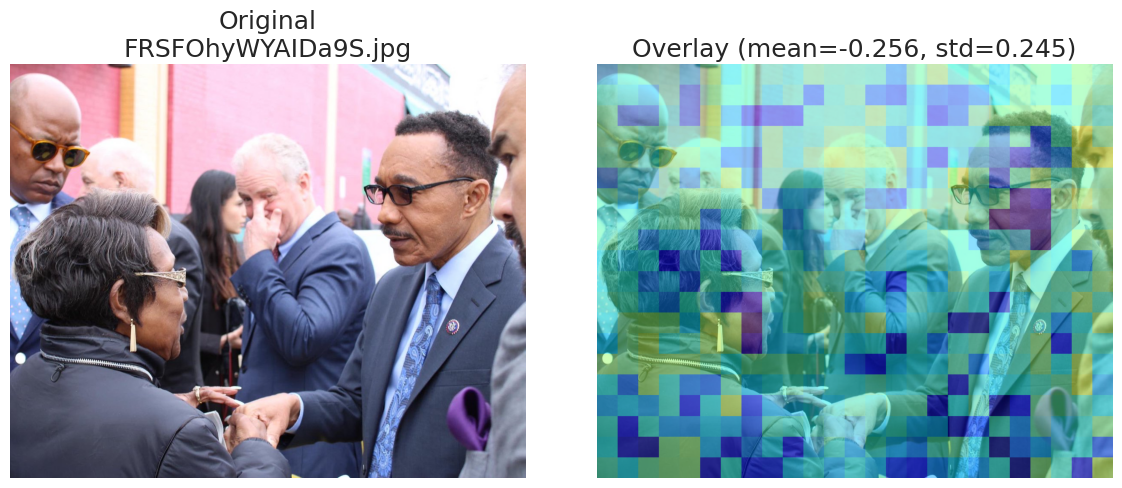

In [12]:
# Helpers to reconstruct per-image score maps and overlay heatmaps.
def get_image_scores_for_index(idx: int):
    offsets = payload["offsets"].numpy()
    scores = payload["scores"].numpy()
    start, end = int(offsets[idx]), int(offsets[idx + 1])
    return scores[start:end]

def overlay_heatmap_on_image(img_pil, heatmap_hw, alpha=0.45, cmap="jet", vmin=None, vmax=None):
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    H, W = img.shape[:2]

    hm = heatmap_hw.astype(np.float32)
    if vmin is None:
        vmin = float(np.nanmin(hm))
    if vmax is None:
        vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)

    hm_up = np.array(
        Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.Resampling.NEAREST)
    ) / 255.0

    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]
    out = (1 - alpha) * img + alpha * hm_rgb
    return np.clip(out, 0.0, 1.0)

def show_heatmap_examples(n=6, seed=7):
    n_total = len(payload["image_paths"])
    if n_total == 0:
        print("No images in payload.")
        return

    rng = np.random.default_rng(seed)
    choices = rng.choice(n_total, size=min(n, n_total), replace=False)

    for idx in choices:
        image_path = payload["image_paths"][idx]
        grid_h, grid_w = payload["grid_hw"][idx].tolist()
        flat_scores = get_image_scores_for_index(idx)

        if len(flat_scores) != grid_h * grid_w:
            print(f"Skipping {image_path}: score length mismatch")
            continue

        heat = flat_scores.reshape(grid_h, grid_w)
        img = Image.open(image_path).convert("RGB")
        over = overlay_heatmap_on_image(img, heat, alpha=0.45, cmap="jet", vmin=-1, vmax=1)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img)
        axes[0].set_title(f"Original\n{Path(image_path).name}")
        axes[0].axis("off")

        axes[1].imshow(over)
        axes[1].set_title(
            f"Overlay (mean={float(np.mean(flat_scores)):.3f}, std={float(np.std(flat_scores)):.3f})"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

show_heatmap_examples(n=6, seed=7)

,count,mean,std,min,25%,50%,75%,max
mean,1367.0,-0.079593,0.125043,-0.527922,-0.159971,-0.075310,0.008156,0.354887
median,1367.0,-0.074377,0.107974,-0.485779,-0.145031,-0.069641,0.003845,0.213257
min,1367.0,-0.774376,0.327025,-2.235352,-0.964447,-0.718018,-0.530853,-0.211487
max,1367.0,0.647088,0.319539,0.107788,0.431091,0.577251,0.787216,2.335510
std,1367.0,0.201140,0.047697,0.102376,0.168478,0.193959,0.225895,0.488710
num_patches,1367.0,473.460132,184.320496,64.000000,350.000000,425.000000,576.000000,950.000000


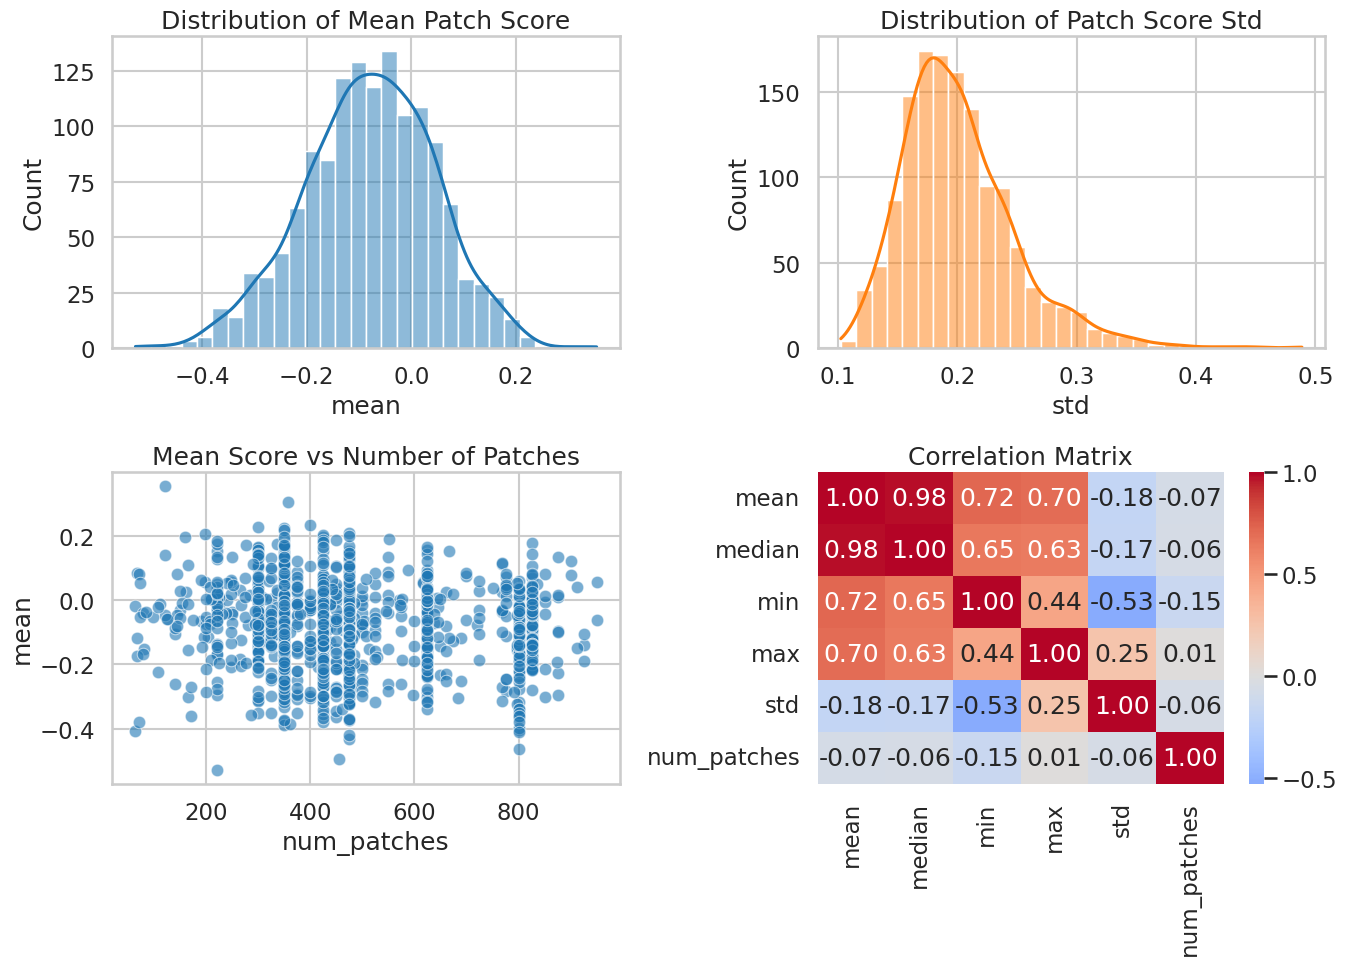

Top 10 by mean score


,image_name,image_path,num_patches,mean,std,min,max
966,FG0NSWNXwAQslxo.jpg,data/twitter_images/FG0NSWNXwAQslxo.jpg,120,0.354887,0.488710,-0.356995,1.966919
851,EvZ3J8yWYAgN3OE.png,data/twitter_images/EvZ3J8yWYAgN3OE.png,357,0.304984,0.411964,-0.347046,2.025879
308,DiVxb-aVMAAvbXr.jpg,data/twitter_images/DiVxb-aVMAAvbXr.jpg,400,0.234435,0.431957,-0.589645,2.335510
352,DomOoaLUUAEWpFH.jpg,data/twitter_images/DomOoaLUUAEWpFH.jpg,300,0.227244,0.316651,-0.339043,1.585938
214,DRb1zLfXkAIhafu.jpg,data/twitter_images/DRb1zLfXkAIhafu.jpg,350,0.224800,0.278346,-0.379028,1.553101
596,EOm8lGKWAAAJVkT.jpg,data/twitter_images/EOm8lGKWAAAJVkT.jpg,350,0.220543,0.320699,-0.471680,1.730896
617,ERt2ZsQWAAUtBgd.jpg,data/twitter_images/ERt2ZsQWAAUtBgd.jpg,475,0.210989,0.246837,-0.393242,1.908478
142,DH26SqFWsAAXxsA.jpg,data/twitter_images/DH26SqFWsAAXxsA.jpg,198,0.205433,0.322018,-0.479370,1.441406
470,E7RCt05XsAEqvxs.jpg,data/twitter_images/E7RCt05XsAEqvxs.jpg,425,0.202245,0.351061,-0.853394,1.609589
1167,FdrmsdcXEAAFa_V.jpg,data/twitter_images/FdrmsdcXEAAFa_V.jpg,475,0.198894,0.181012,-0.280029,1.094116


Bottom 10 by mean score


,image_name,image_path,num_patches,mean,std,min,max
1021,FNByIURXwAE3ZIo.jpg,data/twitter_images/FNByIURXwAE3ZIo.jpg,220,-0.527922,0.312740,-1.216675,0.232788
994,FJ9E-TAXoAIWQNY.jpg,data/twitter_images/FJ9E-TAXoAIWQNY.jpg,456,-0.495827,0.354727,-1.690552,0.158081
423,E16-Bn_WYAAfe46.png,data/twitter_images/E16-Bn_WYAAfe46.png,800,-0.464152,0.364066,-1.691528,0.362366
752,EgxBejAWkAI962m.jpg,data/twitter_images/EgxBejAWkAI962m.jpg,475,-0.433024,0.293150,-1.663574,0.164307
986,FI_XKhqVQAILEyI.jpg,data/twitter_images/FI_XKhqVQAILEyI.jpg,475,-0.418327,0.300923,-1.909424,0.188049
1055,FQuoQrzWUA4y0w3.jpg,data/twitter_images/FQuoQrzWUA4y0w3.jpg,800,-0.411362,0.373929,-1.718872,0.479248
366,DtWmE93XgAATlD8.jpg,data/twitter_images/DtWmE93XgAATlD8.jpg,64,-0.408213,0.190386,-0.849487,0.310043
277,DcIJXCLWsAEjTnx.jpg,data/twitter_images/DcIJXCLWsAEjTnx.jpg,800,-0.404369,0.344219,-1.676880,0.179443
829,EtvUkvUXAAABbW0.jpg,data/twitter_images/EtvUkvUXAAABbW0.jpg,800,-0.399294,0.365202,-1.886108,0.251953
835,EuDvVgGWYAcVKQq.jpg,data/twitter_images/EuDvVgGWYAcVKQq.jpg,350,-0.389060,0.264193,-1.251221,0.267319


In [13]:
# Statistical views of per-image probing scores.
df_plot = df_stats.copy()

required_cols = ["mean", "median", "min", "max", "std", "num_patches"]
missing = [c for c in required_cols if c not in df_plot.columns]
if missing:
    raise ValueError(f"Missing expected columns in stats CSV: {missing}")

summary = df_plot[required_cols].describe().T
display(summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_plot["mean"], bins=30, kde=True, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Distribution of Mean Patch Score")

sns.histplot(df_plot["std"], bins=30, kde=True, ax=axes[0, 1], color="tab:orange")
axes[0, 1].set_title("Distribution of Patch Score Std")

sns.scatterplot(data=df_plot, x="num_patches", y="mean", alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Mean Score vs Number of Patches")

corr_cols = ["mean", "median", "min", "max", "std", "num_patches"]
corr = df_plot[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0.0, annot=True, fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

cols_to_show = [c for c in ["image_name", "image_path", "num_patches", "mean", "std", "min", "max"] if c in df_plot.columns]
print("Top 10 by mean score")
display(df_plot.sort_values("mean", ascending=False)[cols_to_show].head(10))

print("Bottom 10 by mean score")
display(df_plot.sort_values("mean", ascending=True)[cols_to_show].head(10))

No rich account/source hierarchy detected in image paths; using patch_bin x format grouping instead.
Top patch count bin groups by image count


,patch_bin,n_images,mean_score,median_score
0,"(425.0, 475.0]",284,-0.089135,-0.088326
1,"(63.999, 325.0]",242,-0.057900,-0.054760
2,"(325.0, 350.0]",230,-0.064925,-0.080840
3,"(660.0, 950.0]",227,-0.088819,-0.077680
4,"(350.0, 425.0]",213,-0.094256,-0.098056
5,"(475.0, 660.0]",171,-0.083664,-0.070277


Top image format groups by image count


,format,n_images,mean_score,median_score
0,jpg,1279,-0.080461,-0.078304
1,png,88,-0.066972,-0.053975


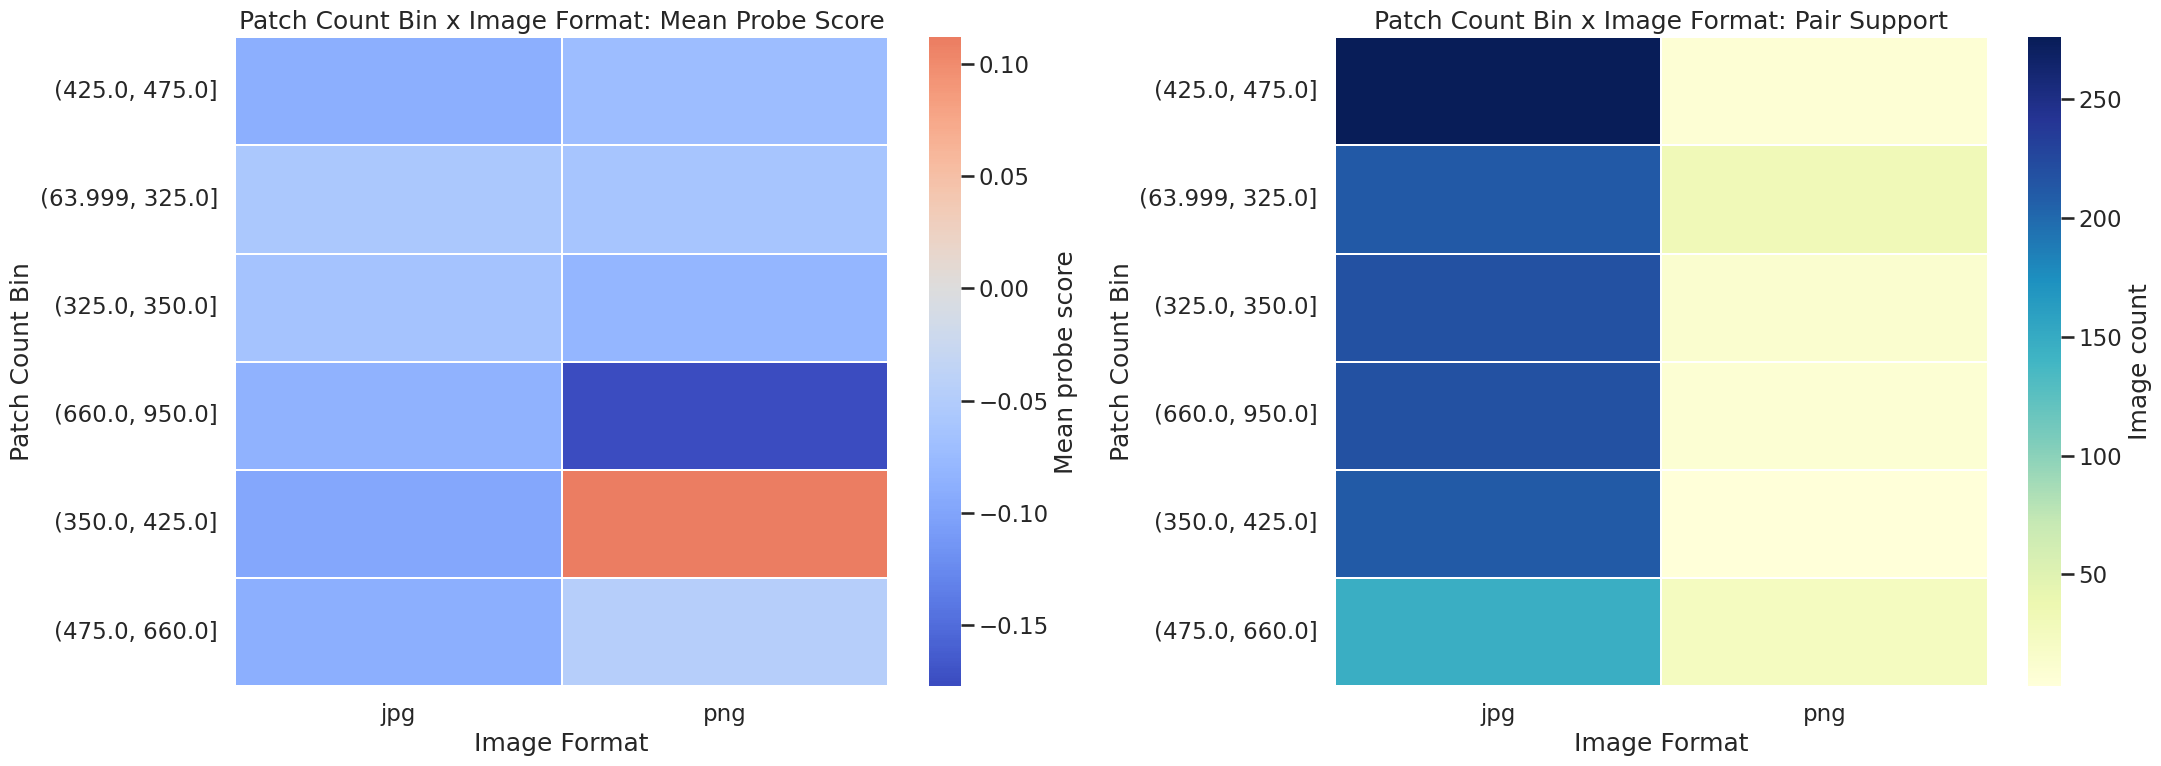

,patch_bin,format,pair_count,pair_mean_score,pair_median_score
4,"(425.0, 475.0]",jpg,276,-0.089613,-0.090394
0,"(325.0, 350.0]",jpg,218,-0.064045,-0.083312
10,"(660.0, 950.0]",jpg,218,-0.085173,-0.076270
8,"(63.999, 325.0]",jpg,211,-0.057381,-0.051372
2,"(350.0, 425.0]",jpg,210,-0.097198,-0.100940
6,"(475.0, 660.0]",jpg,146,-0.089919,-0.075393
9,"(63.999, 325.0]",png,31,-0.061434,-0.063527
7,"(475.0, 660.0]",png,25,-0.047136,-0.014933
1,"(325.0, 350.0]",png,12,-0.080906,-0.050470
11,"(660.0, 950.0]",png,9,-0.177116,-0.119139


In [14]:
# Visualize probing scores by account x source when available; otherwise use format x patch-bin.
import re

if "df_stats" not in globals():
    raise RuntimeError("Run the data-loading cell first so df_stats is available.")

df_group = df_stats.copy()

if "image_path" not in df_group.columns or "mean" not in df_group.columns:
    raise ValueError("Expected columns ['image_path', 'mean'] in df_stats.")

def parse_account_source(path_str: str):
    p = str(path_str).replace("\\", "/")
    parts = [x for x in p.split("/") if x]

    account = None
    source = None
    if len(parts) >= 3:
        account = re.sub(r"[_-]+", " ", parts[-3]).strip().title()
        source = re.sub(r"[_-]+", " ", parts[-2]).strip().title()
    return account, source

parsed = df_group["image_path"].apply(parse_account_source)
df_group[["account", "source"]] = pd.DataFrame(parsed.tolist(), index=df_group.index)

use_account_source = (
    df_group["account"].notna().any()
    and df_group["source"].notna().any()
    and df_group["account"].nunique(dropna=True) > 1
    and df_group["source"].nunique(dropna=True) > 1
)

if use_account_source:
    row_col_name = ("account", "source")
    row_label, col_label = "Account", "Source"
else:
    df_group["format"] = df_group["image_path"].apply(lambda p: Path(p).suffix.lower().lstrip(".") or "unknown")

    n_unique_patches = int(df_group["num_patches"].nunique()) if "num_patches" in df_group.columns else 0
    n_bins = max(2, min(6, n_unique_patches)) if n_unique_patches > 1 else 2
    df_group["patch_bin"] = pd.qcut(
        df_group["num_patches"],
        q=n_bins,
        duplicates="drop",
    ).astype(str)

    row_col_name = ("patch_bin", "format")
    row_label, col_label = "Patch Count Bin", "Image Format"
    print("No rich account/source hierarchy detected in image paths; using patch_bin x format grouping instead.")

row_name, col_name = row_col_name

row_stats = (
    df_group.groupby(row_name, as_index=False)
    .agg(n_images=("mean", "size"), mean_score=("mean", "mean"), median_score=("mean", "median"))
    .sort_values("n_images", ascending=False)
    .reset_index(drop=True)
)

col_stats = (
    df_group.groupby(col_name, as_index=False)
    .agg(n_images=("mean", "size"), mean_score=("mean", "mean"), median_score=("mean", "median"))
    .sort_values("n_images", ascending=False)
    .reset_index(drop=True)
)

print(f"Top {row_label.lower()} groups by image count")
display(row_stats.head(15))

print(f"Top {col_label.lower()} groups by image count")
display(col_stats.head(15))

TOP_ROWS = 20
TOP_COLS = 20
MIN_PAIR_COUNT = 2

top_rows = row_stats.head(TOP_ROWS)[row_name].tolist()
top_cols = col_stats.head(TOP_COLS)[col_name].tolist()

pair_stats = (
    df_group[df_group[row_name].isin(top_rows) & df_group[col_name].isin(top_cols)]
    .groupby([row_name, col_name], as_index=False)
    .agg(pair_count=("mean", "size"), pair_mean_score=("mean", "mean"), pair_median_score=("mean", "median"))
)

pair_stats = pair_stats[pair_stats["pair_count"] >= MIN_PAIR_COUNT].copy()

if pair_stats.empty:
    print("No row x column pairs passed MIN_PAIR_COUNT. Lower MIN_PAIR_COUNT to visualize more pairs.")
else:
    pivot_mean = pair_stats.pivot(index=row_name, columns=col_name, values="pair_mean_score")
    pivot_count = pair_stats.pivot(index=row_name, columns=col_name, values="pair_count")

    row_order = pivot_count.sum(axis=1).sort_values(ascending=False).index
    col_order = pivot_count.sum(axis=0).sort_values(ascending=False).index
    pivot_mean = pivot_mean.loc[row_order, col_order]
    pivot_count = pivot_count.loc[row_order, col_order]

    fig, axes = plt.subplots(1, 2, figsize=(22, max(8, 0.45 * len(row_order))))

    sns.heatmap(
        pivot_mean,
        ax=axes[0],
        cmap="coolwarm",
        center=0.0,
        cbar_kws={"label": "Mean probe score"},
        linewidths=0.2,
        linecolor="white",
    )
    axes[0].set_title(f"{row_label} x {col_label}: Mean Probe Score")
    axes[0].set_xlabel(col_label)
    axes[0].set_ylabel(row_label)

    sns.heatmap(
        pivot_count,
        ax=axes[1],
        cmap="YlGnBu",
        cbar_kws={"label": "Image count"},
        linewidths=0.2,
        linecolor="white",
    )
    axes[1].set_title(f"{row_label} x {col_label}: Pair Support")
    axes[1].set_xlabel(col_label)
    axes[1].set_ylabel(row_label)

    plt.tight_layout()
    plt.show()

display(pair_stats.sort_values(["pair_count", "pair_mean_score"], ascending=[False, False]).head(50))

Join mode: url basename (image_name <-> url)
Matched party labels: 1367/1367


,party,n_images,mean_of_mean,median_of_mean,std_of_mean,mean_patch_std,mean_num_patches
0,Democrat,817,-0.119385,-0.117580,0.117573,0.204504,471.182375
1,Republican,547,-0.020496,-0.011519,0.112103,0.195922,476.579525


/scratch/local/jobs/48592966/ipykernel_3632718/3031724003.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_party, x="party", y="mean", palette="Set2", ax=axes[0])
/scratch/local/jobs/48592966/ipykernel_3632718/3031724003.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_party, x="party", y="mean", inner="quartile", palette="Set2", ax=axes[1])
/scratch/local/jobs/48592966/ipykernel_3632718/3031724003.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_summary, x="party", y="n_images", palette="Set2", ax=a

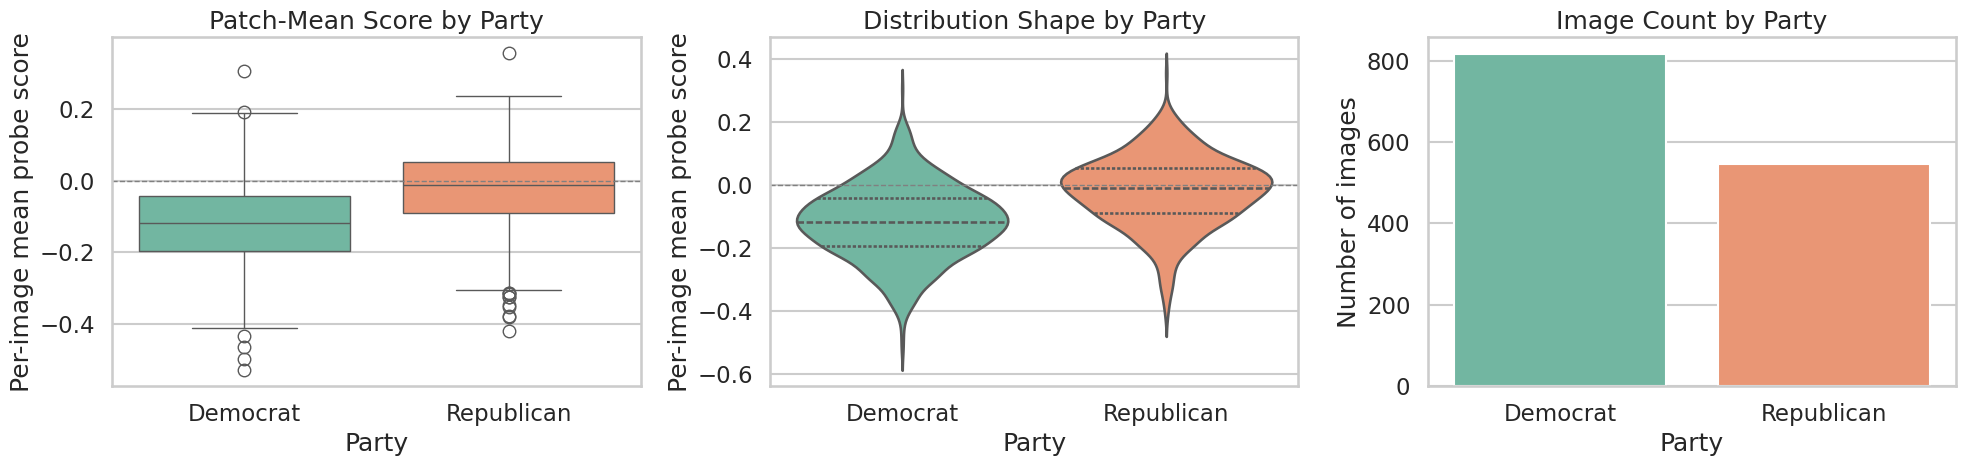

,party,q05,q25,q50,q75,q95
0,Democrat,-0.313000,-0.195229,-0.117580,-0.042150,0.072350
1,Republican,-0.208631,-0.091158,-0.011519,0.052812,0.151969


In [15]:
# Compare probing-score stats between the two parties.
meta_path = Path("data/twitter_images_metadata.csv")
if not meta_path.exists():
    raise FileNotFoundError(f"Missing metadata file: {meta_path}")

df_meta = pd.read_csv(meta_path)
required_meta_cols = {"party", "url", "filename"}
missing_meta_cols = required_meta_cols - set(df_meta.columns)
if missing_meta_cols:
    raise ValueError(f"Missing required metadata columns: {sorted(missing_meta_cols)}")

df_cmp = df_stats.copy()
df_cmp["image_name"] = df_cmp["image_name"].astype(str)
df_cmp["image_basename"] = df_cmp["image_path"].astype(str).apply(lambda p: Path(p).name)

df_meta = df_meta.copy()
df_meta["url_name"] = df_meta["url"].astype(str).apply(lambda u: Path(u).name)
df_meta["filename"] = df_meta["filename"].astype(str)
df_meta["party"] = df_meta["party"].astype(str).str.strip()

# Use whichever key recovers more party labels.
meta_by_url = df_meta[["url_name", "party"]].drop_duplicates("url_name")
meta_by_file = df_meta[["filename", "party"]].drop_duplicates("filename")

df_url_join = df_cmp.merge(meta_by_url, how="left", left_on="image_name", right_on="url_name")
url_match_count = int(df_url_join["party"].notna().sum())

df_file_join = df_cmp.merge(meta_by_file, how="left", left_on="image_basename", right_on="filename")
file_match_count = int(df_file_join["party"].notna().sum())

if url_match_count >= file_match_count:
    df_party = df_url_join.copy()
    join_mode = "url basename (image_name <-> url)"
else:
    df_party = df_file_join.copy()
    join_mode = "local filename (image_path basename <-> filename)"

print(f"Join mode: {join_mode}")
print(f"Matched party labels: {int(df_party['party'].notna().sum())}/{len(df_party)}")

df_party = df_party[df_party["party"].isin(["Democrat", "Republican"])].copy()
if df_party.empty:
    raise RuntimeError("No Democrat/Republican rows available after merge. Check metadata alignment.")

party_summary = (
    df_party.groupby("party", as_index=False)
    .agg(
        n_images=("mean", "size"),
        mean_of_mean=("mean", "mean"),
        median_of_mean=("mean", "median"),
        std_of_mean=("mean", "std"),
        mean_patch_std=("std", "mean"),
        mean_num_patches=("num_patches", "mean"),
    )
    .sort_values("party")
    .reset_index(drop=True)
)

display(party_summary)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(data=df_party, x="party", y="mean", palette="Set2", ax=axes[0])
axes[0].axhline(0.0, linestyle="--", linewidth=1, color="gray")
axes[0].set_title("Patch-Mean Score by Party")
axes[0].set_xlabel("Party")
axes[0].set_ylabel("Per-image mean probe score")

sns.violinplot(data=df_party, x="party", y="mean", inner="quartile", palette="Set2", ax=axes[1])
axes[1].axhline(0.0, linestyle="--", linewidth=1, color="gray")
axes[1].set_title("Distribution Shape by Party")
axes[1].set_xlabel("Party")
axes[1].set_ylabel("Per-image mean probe score")

sns.barplot(data=party_summary, x="party", y="n_images", palette="Set2", ax=axes[2])
axes[2].set_title("Image Count by Party")
axes[2].set_xlabel("Party")
axes[2].set_ylabel("Number of images")

plt.tight_layout()
plt.show()

# Optional: show party-level quantiles for the score distribution.
q = (
    df_party.groupby("party")["mean"]
    .quantile([0.05, 0.25, 0.5, 0.75, 0.95])
    .unstack()
    .rename(columns={0.05: "q05", 0.25: "q25", 0.5: "q50", 0.75: "q75", 0.95: "q95"})
    .reset_index()
    .sort_values("party")
)
display(q)

,metric,value
0,n_democrat,8.170000e+02
1,n_republican,5.470000e+02
2,mean_diff_rep_minus_dem,9.888919e-02
3,mean_diff_bootstrap_ci_low,8.632473e-02
4,mean_diff_bootstrap_ci_high,1.111855e-01
5,welch_t_stat,-1.565650e+01
6,welch_t_pvalue,1.918192e-50
7,mannwhitney_u_stat,1.174550e+05
8,mannwhitney_u_pvalue,5.460162e-50
9,cohens_d,8.568438e-01


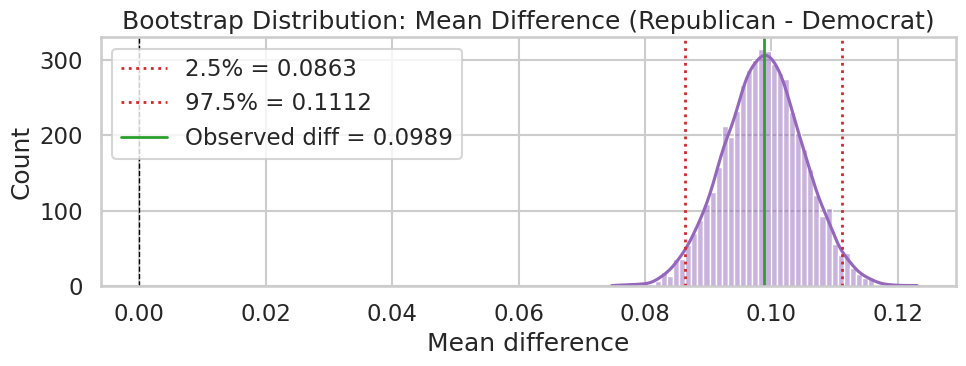

In [16]:
# Statistical inference for party differences in per-image mean probe score.
if "df_party" not in globals() or "party" not in df_party.columns:
    raise RuntimeError("Run Cell 7 first to build df_party with party labels.")

from scipy import stats

dem = df_party.loc[df_party["party"] == "Democrat", "mean"].dropna().to_numpy()
rep = df_party.loc[df_party["party"] == "Republican", "mean"].dropna().to_numpy()

if len(dem) < 2 or len(rep) < 2:
    raise RuntimeError("Not enough samples per party for inference tests.")

# Welch t-test: compares means without equal-variance assumption.
t_stat, t_p = stats.ttest_ind(dem, rep, equal_var=False)

# Mann-Whitney U: non-parametric test for distribution shift.
u_stat, u_p = stats.mannwhitneyu(dem, rep, alternative="two-sided")

# Effect sizes.
mean_diff = float(rep.mean() - dem.mean())
pooled_sd = float(np.sqrt(((len(rep) - 1) * rep.var(ddof=1) + (len(dem) - 1) * dem.var(ddof=1)) / (len(rep) + len(dem) - 2)))
cohens_d = mean_diff / pooled_sd if pooled_sd > 0 else np.nan

# Cliff's delta (ordinal effect size): P(rep > dem) - P(rep < dem).
pairwise = rep[:, None] - dem[None, :]
cliffs_delta = float((np.sum(pairwise > 0) - np.sum(pairwise < 0)) / pairwise.size)

# Bootstrap CI for mean difference (rep - dem).
rng = np.random.default_rng(42)
n_boot = 5000
boot_diffs = np.empty(n_boot, dtype=np.float64)
for i in range(n_boot):
    rep_s = rng.choice(rep, size=len(rep), replace=True)
    dem_s = rng.choice(dem, size=len(dem), replace=True)
    boot_diffs[i] = rep_s.mean() - dem_s.mean()
ci_low, ci_high = np.quantile(boot_diffs, [0.025, 0.975])

results = pd.DataFrame(
    [
        {
            "metric": "n_democrat",
            "value": len(dem),
        },
        {
            "metric": "n_republican",
            "value": len(rep),
        },
        {
            "metric": "mean_diff_rep_minus_dem",
            "value": mean_diff,
        },
        {
            "metric": "mean_diff_bootstrap_ci_low",
            "value": float(ci_low),
        },
        {
            "metric": "mean_diff_bootstrap_ci_high",
            "value": float(ci_high),
        },
        {
            "metric": "welch_t_stat",
            "value": float(t_stat),
        },
        {
            "metric": "welch_t_pvalue",
            "value": float(t_p),
        },
        {
            "metric": "mannwhitney_u_stat",
            "value": float(u_stat),
        },
        {
            "metric": "mannwhitney_u_pvalue",
            "value": float(u_p),
        },
        {
            "metric": "cohens_d",
            "value": float(cohens_d),
        },
        {
            "metric": "cliffs_delta",
            "value": float(cliffs_delta),
        },
    ]
)

display(results)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.histplot(boot_diffs, bins=50, kde=True, color="tab:purple", ax=ax)
ax.axvline(0.0, linestyle="--", color="black", linewidth=1)
ax.axvline(ci_low, linestyle=":", color="tab:red", linewidth=2, label=f"2.5% = {ci_low:.4f}")
ax.axvline(ci_high, linestyle=":", color="tab:red", linewidth=2, label=f"97.5% = {ci_high:.4f}")
ax.axvline(mean_diff, linestyle="-", color="tab:green", linewidth=2, label=f"Observed diff = {mean_diff:.4f}")
ax.set_title("Bootstrap Distribution: Mean Difference (Republican - Democrat)")
ax.set_xlabel("Mean difference")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

Rows with DW-NOMINATE match: 4972/5339


,metric,value
0,n_rows,4.972000e+03
1,n_unique_members,2.590000e+02
2,pearson_r,4.136497e-01
3,pearson_p,8.064686e-205
4,spearman_rho,3.957212e-01
5,spearman_p,4.523208e-186


,metric,value
0,member_level_n,2.590000e+02
1,member_level_pearson_r,5.801093e-01
2,member_level_pearson_p,1.081684e-24
3,member_level_spearman_rho,5.637235e-01
4,member_level_spearman_p,3.989388e-23


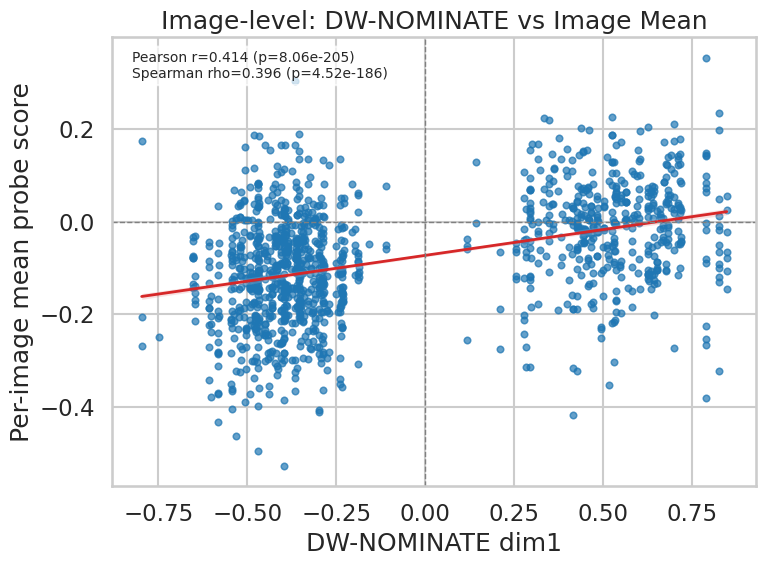

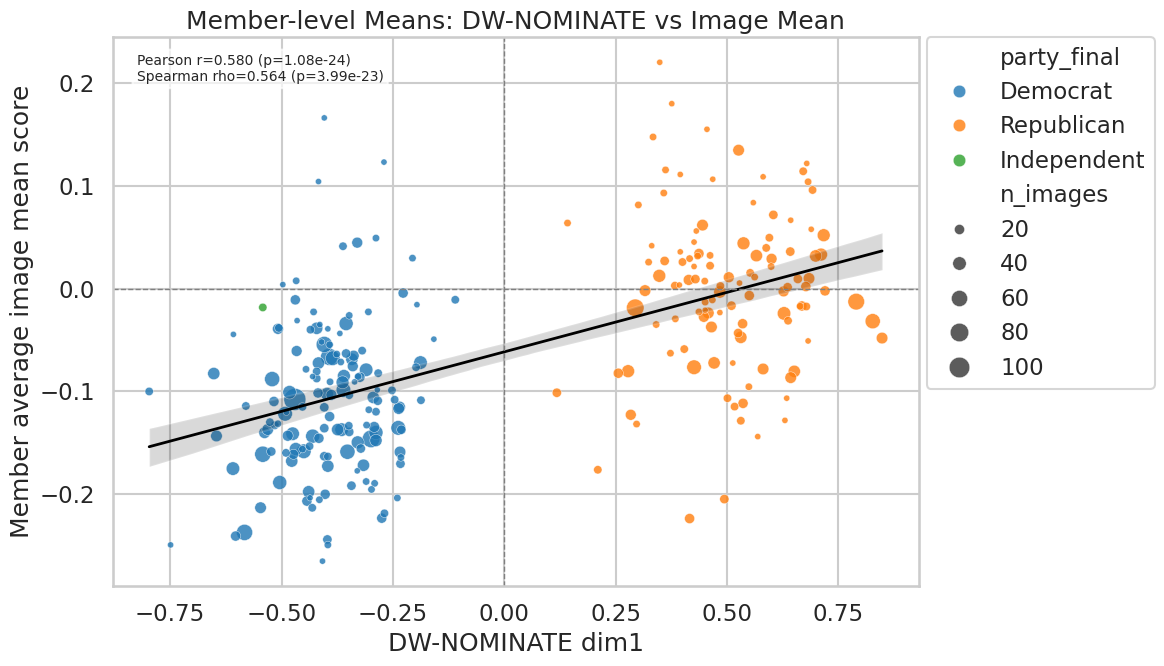

,bioguide,name,party_final,nominate_dim1,n_images,mean_image_score,std_image_score
0,E000296,Dwight Evans,Democrat,-0.470,116,-0.107946,0.147034
1,T000468,Dina Titus,Democrat,-0.299,72,-0.146323,0.125619
2,B001298,Don Bacon,Republican,0.294,72,-0.018667,0.109434
3,T000460,Mike Thompson,Democrat,-0.393,68,-0.066400,0.099046
4,C001098,Ted Cruz,Republican,0.790,64,-0.012664,0.188423
5,E000297,Adriano Espaillat,Democrat,-0.583,60,-0.237492,0.119905
6,G000585,Jimmy Gomez,Democrat,-0.542,60,-0.161291,0.123230
7,C001091,Joaquin Castro,Democrat,-0.404,60,-0.054399,0.090530
8,R000606,Jamie Raskin,Democrat,-0.521,52,-0.088103,0.110050
9,M001111,Patty Murray,Democrat,-0.352,52,-0.158861,0.069653


In [25]:
# Correlate DW-NOMINATE (dim1) with image token mean scores.
if "df_stats" not in globals():
    raise RuntimeError("Run Cell 3 first so df_stats is available.")

from scipy import stats

meta_path = Path("data/twitter_images_metadata.csv")
leg_path = Path("data/legislators_116_119_with_twitter.csv")
dw_path = Path("data/HS116_members.csv")

for p in [meta_path, leg_path, dw_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

df_meta = pd.read_csv(meta_path)
df_leg = pd.read_csv(leg_path)
df_dw = pd.read_csv(dw_path)

# Attach a stable image key so stats can join to metadata by URL basename.
df_img = df_stats.copy()
df_img["image_name"] = df_img["image_name"].astype(str)

df_meta = df_meta.copy()
df_meta["url_name"] = df_meta["url"].astype(str).apply(lambda u: Path(u).name)
df_meta["screen_key"] = df_meta["screen_name"].astype(str).str.strip().str.lower().str.lstrip("@")

df_leg = df_leg.copy()
df_leg["twitter_key"] = df_leg["twitter"].astype(str).str.strip().str.lower().str.lstrip("@")

df_dw = df_dw.copy()
df_dw = df_dw[df_dw["congress"] == 116].copy()
df_dw["bioguide_id"] = df_dw["bioguide_id"].astype(str)

# Keep one DW row per bioguide in case of duplicate entries.
dw_cols = ["bioguide_id", "nominate_dim1", "nominate_dim2", "party_code", "bioname"]
df_dw = df_dw[dw_cols].dropna(subset=["bioguide_id", "nominate_dim1"]).drop_duplicates("bioguide_id")

df_join = (
    df_img.merge(df_meta[["url_name", "screen_key", "party"]], how="left", left_on="image_name", right_on="url_name")
    .merge(df_leg[["twitter_key", "bioguide", "name", "party"]], how="left", left_on="screen_key", right_on="twitter_key", suffixes=("_meta", "_leg"))
    .merge(df_dw, how="left", left_on="bioguide", right_on="bioguide_id")
)

df_join["party_final"] = df_join["party_meta"].fillna(df_join["party_leg"]).fillna("Unknown")

matched = int(df_join["nominate_dim1"].notna().sum())
print(f"Rows with DW-NOMINATE match: {matched}/{len(df_join)}")

df_corr = df_join.dropna(subset=["nominate_dim1", "mean"]).copy()
if len(df_corr) < 10:
    raise RuntimeError("Too few rows after joining nominate_dim1 with image means.")

# Correlations across all matched images.
pearson_r, pearson_p = stats.pearsonr(df_corr["nominate_dim1"], df_corr["mean"])
spearman_rho, spearman_p = stats.spearmanr(df_corr["nominate_dim1"], df_corr["mean"])

corr_table = pd.DataFrame(
    [
        {"metric": "n_rows", "value": len(df_corr)},
        {"metric": "n_unique_members", "value": df_corr["bioguide"].nunique()},
        {"metric": "pearson_r", "value": float(pearson_r)},
        {"metric": "pearson_p", "value": float(pearson_p)},
        {"metric": "spearman_rho", "value": float(spearman_rho)},
        {"metric": "spearman_p", "value": float(spearman_p)},
    ]
)
display(corr_table)

# Member-level aggregation to avoid high-volume accounts dominating the fit.
member_agg = (
    df_corr.groupby(["bioguide", "name", "party_final", "nominate_dim1"], as_index=False)
    .agg(
        n_images=("mean", "size"),
        mean_image_score=("mean", "mean"),
        std_image_score=("mean", "std"),
    )
    .sort_values("n_images", ascending=False)
    .reset_index(drop=True)
)

pearson_m_r, pearson_m_p = stats.pearsonr(member_agg["nominate_dim1"], member_agg["mean_image_score"])
spearman_m_rho, spearman_m_p = stats.spearmanr(member_agg["nominate_dim1"], member_agg["mean_image_score"])

member_corr_table = pd.DataFrame(
    [
        {"metric": "member_level_n", "value": len(member_agg)},
        {"metric": "member_level_pearson_r", "value": float(pearson_m_r)},
        {"metric": "member_level_pearson_p", "value": float(pearson_m_p)},
        {"metric": "member_level_spearman_rho", "value": float(spearman_m_rho)},
        {"metric": "member_level_spearman_p", "value": float(spearman_m_p)},
    ]
)
display(member_corr_table)

# Image-level plot.
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.regplot(
    data=df_corr,
    x="nominate_dim1",
    y="mean",
    scatter_kws={"alpha": 0.25, "s": 22},
    line_kws={"color": "tab:red", "linewidth": 2},
    ax=ax,
)
ax.axvline(0.0, linestyle="--", color="gray", linewidth=1)
ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
ax.set_title("Image-level: DW-NOMINATE vs Image Mean")
ax.set_xlabel("DW-NOMINATE dim1")
ax.set_ylabel("Per-image mean probe score")
ax.text(
    0.03,
    0.97,
    f"Pearson r={pearson_r:.3f} (p={pearson_p:.2e})\nSpearman rho={spearman_rho:.3f} (p={spearman_p:.2e})",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
)
plt.tight_layout()
plt.show()

# Member-level plot.
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
sns.scatterplot(
    data=member_agg,
    x="nominate_dim1",
    y="mean_image_score",
    hue="party_final",
    size="n_images",
    sizes=(20, 250),
    alpha=0.8,
    ax=ax,
)
sns.regplot(
    data=member_agg,
    x="nominate_dim1",
    y="mean_image_score",
    scatter=False,
    line_kws={"color": "black", "linewidth": 2},
    ax=ax,
)
ax.axvline(0.0, linestyle="--", color="gray", linewidth=1)
ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
ax.set_title("Member-level Means: DW-NOMINATE vs Image Mean")
ax.set_xlabel("DW-NOMINATE dim1")
ax.set_ylabel("Member average image mean score")
ax.text(
    0.03,
    0.97,
    f"Pearson r={pearson_m_r:.3f} (p={pearson_m_p:.2e})\nSpearman rho={spearman_m_rho:.3f} (p={spearman_m_p:.2e})",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

display(member_agg.head(20))
